# Day 39: KPI Monitoring System for Executives
### 60 Days of Data Science | Phase: Business Intelligence & Dashboards
**Author:** Rajesh Yadav  
**Date:** June 21, 2026  

---

## 1. Project Overview
In a corporate setting, executives require high-level, clear, and actionable insights from data rather than complex machine learning architectures. This project implements a **KPI Monitoring System** that reads raw transaction data and compiles a comprehensive dashboard of key performance indicators.

### Objectives:
- Generate business metrics to track performance, growth, and customer loyalty.
- Produce clean, executive-ready visualizations.
- Provide strategic business insights based on data trends.

### Key Metrics to Calculate:
1. **Total Revenue**: Cumulative revenue generated from all transactions.
2. **Active Customers**: Count of unique Customer IDs in the dataset.
3. **Total Orders**: Total volume of products purchased (cumulative order quantities).
4. **Customer Retention Rate**: Percentage of unique customers who are retained.
5. **Customer Churn Rate**: Percentage of unique customers who churned (100% - Retention Rate).
6. **Average Order Value (AOV)**: Average revenue earned per transaction.
7. **Average Revenue Per Customer (ARPU)**: Average revenue generated per unique active customer.

Let's begin by importing the required python libraries.


## Step 1: Import Python Libraries
We use only standard libraries: Pandas, NumPy, Matplotlib, and Seaborn for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure visualization aesthetics for executive-level presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)


Pandas version: 2.2.3
NumPy version: 2.2.1
Seaborn version: 0.13.2


## Step 2: Load and Inspect the Dataset
We read our generated sales transaction dataset `business_kpi_data.csv` and inspect its properties.

In [2]:
# Load the dataset
df = pd.read_csv('business_kpi_data.csv')

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 records:")
display(df.head())


Dataset Dimensions: 1500 rows, 7 columns

First 5 records:


,Customer_ID,Date,Revenue,Orders,Region,Category,Retained
0,CUST-1029,2025-01-02,8.33,1,North,Books,Yes
1,CUST-1101,2025-01-03,474.99,3,East,Electronics,Yes
2,CUST-1274,2025-01-04,24.58,1,South,Books,Yes
3,CUST-1120,2025-01-04,372.98,3,West,Electronics,Yes
4,CUST-1316,2025-01-04,100.72,1,South,Electronics,Yes


In [3]:
# Inspect columns, data types, and check for missing values
print("Dataset Info:")
df.info()

print("\nNumerical features summary statistics:")
display(df.describe())

print("\nChecking for missing values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  1500 non-null   object 
 1   Date         1500 non-null   object 
 2   Revenue      1500 non-null   float64
 3   Orders       1500 non-null   int64  
 4   Region       1500 non-null   object 
 5   Category     1500 non-null   object 
 6   Retained     1500 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 82.2+ KB

Numerical features summary statistics:


,Revenue,Orders
count,1500.000000,1500.00000
mean,168.012033,1.74200
std,179.139001,1.03028
min,8.040000,1.00000
25%,49.820000,1.00000
50%,109.810000,1.00000
75%,223.747500,2.00000
max,1347.670000,5.00000



Checking for missing values:
Customer_ID    0
Date           0
Revenue        0
Orders         0
Region         0
Category       0
Retained       0
dtype: int64


## Step 3: Calculate Executive Key Performance Indicators (KPIs)
Now we process the transaction columns to compute the metrics. Note that `Retained` status is customer-centric, so we aggregate it at the individual customer level.

In [4]:
# 1. Total Revenue
total_revenue = df['Revenue'].sum()

# 2. Active Customers
active_customers = df['Customer_ID'].nunique()

# 3. Total Transactions & Total Items Ordered
total_transactions = len(df)
total_orders = df['Orders'].sum()

# 4. Retention & Churn Rates (computed at Customer Level)
customer_status = df.groupby('Customer_ID')['Retained'].first()
total_unique_customers = len(customer_status)
retained_customers = (customer_status == 'Yes').sum()

retention_rate = (retained_customers / total_unique_customers) * 100
churn_rate = 100 - retention_rate

# 5. Average Order Value (AOV)
aov = total_revenue / total_transactions

# 6. Average Revenue Per Customer (ARPU)
arpu = total_revenue / active_customers

# Display results in a simple, clean format
print("Executive KPI Summary:")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Active Customers: {active_customers:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Items Ordered: {total_orders:,}")
print(f"Customer Retention Rate: {retention_rate:.2f}%")
print(f"Customer Churn Rate: {churn_rate:.2f}%")
print(f"Average Order Value (AOV): ${aov:.2f} per transaction")
print(f"Average Revenue per Customer (ARPU): ${arpu:.2f}")

Executive KPI Summary:
Total Revenue: $252,018.05
Active Customers: 339
Total Transactions: 1,500
Total Items Ordered: 2,613
Customer Retention Rate: 71.09%
Customer Churn Rate: 28.91%
Average Order Value (AOV): $168.01 per transaction
Average Revenue per Customer (ARPU): $743.42


## Step 4: Visualizations for the Executive Presentation
Executives require intuitive and visually appealing charts to absorb insights quickly. We will plot the 4 requested charts and save them as images.

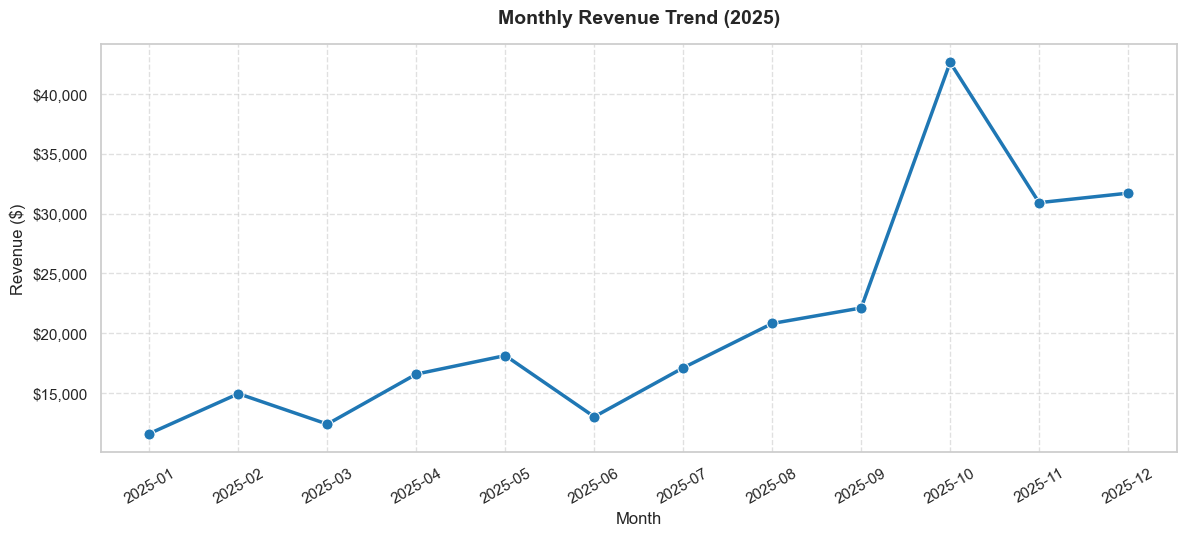

In [5]:
# Convert Date to datetime and create a sorted Monthly label
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month_Str'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(12, 5.5))
# Using a clean blue tone and markers
sns.lineplot(data=monthly_revenue, x='Month_Str', y='Revenue', marker='o', color='#1f77b4', linewidth=2.5, markersize=8)

plt.title('Monthly Revenue Trend (2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('revenue_trend_over_time.png', bbox_inches='tight', dpi=150)
plt.show()


C:\Rtemp\ipykernel_18984\706264981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=region_revenue, x='Region', y='Revenue', palette='Blues_r')


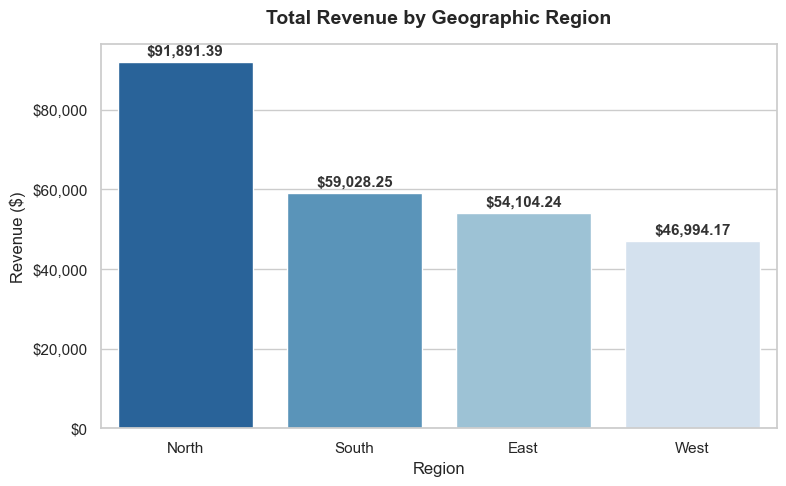

In [6]:
# Group and sort by region revenue
region_revenue = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=region_revenue, x='Region', y='Revenue', palette='Blues_r')

plt.title('Total Revenue by Geographic Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Display values on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"${height:,.2f}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontweight='semibold',
                color='#333333')

plt.tight_layout()
plt.savefig('revenue_by_region.png', bbox_inches='tight', dpi=150)
plt.show()


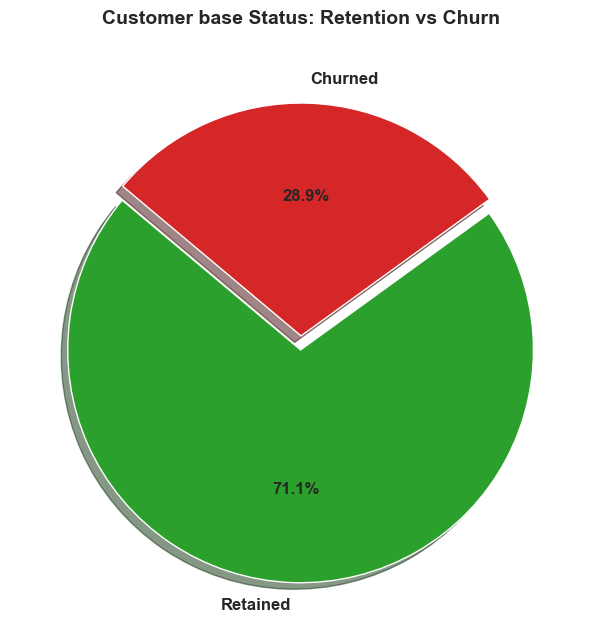

In [7]:
# Plotting Retention vs Churn Pie Chart
status_counts = customer_status.value_counts()
labels = ['Retained', 'Churned']
colors = ['#2ca02c', '#d62728'] # Green for Retained, Red for Churn

plt.figure(figsize=(6.5, 6.5))
plt.pie(status_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0.06, 0), shadow=True, 
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('Customer base Status: Retention vs Churn', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('retention_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()


C:\Rtemp\ipykernel_18984\3107011656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=category_revenue, x='Revenue', y='Category', palette='viridis')


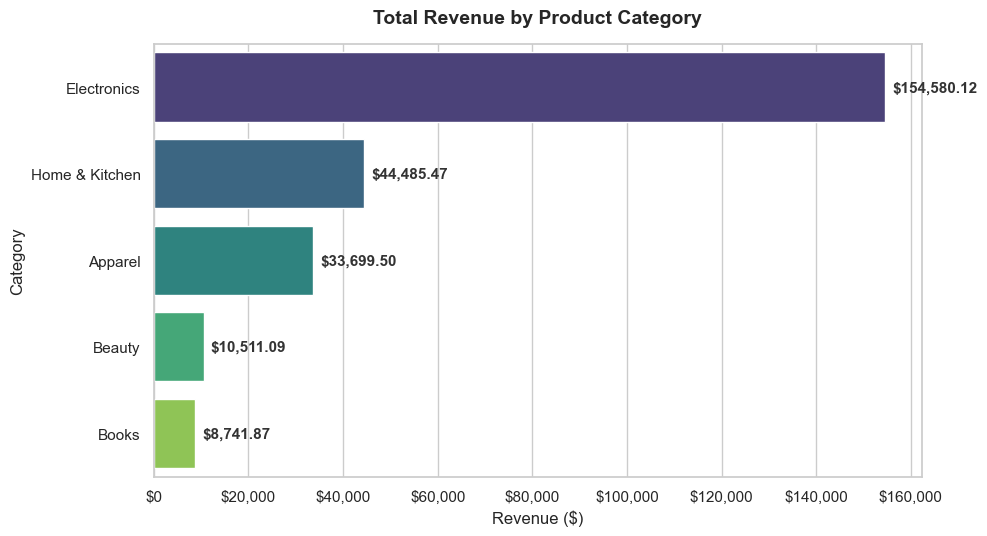

In [8]:
# Category revenue breakdown
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=category_revenue, x='Revenue', y='Category', palette='viridis')

plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Display values inside/next to the horizontal bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"${width:,.2f}",
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontweight='semibold',
                color='#333333')

plt.tight_layout()
plt.savefig('revenue_by_category.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 5: Executive Business Insights & Strategic Recommendations
Based on the metrics and visual analysis, we offer the following key insights for the executive team:

1. **Clear Seasonality Trend**: Monthly revenue remains relatively stable through Q1-Q3 (~$20k-$25k range) but experiences an explosive spike in **Q4** (specifically November and December), peaking near double the early-year baseline. This indicates a high reliance on holiday shopping cycles. 
   - *Recommendation*: Increase marketing budget allocation in Q3 to capture top-of-funnel customer interest ahead of the Q4 holiday surge.
2. **Dominance of Northern Market**: The **North** region generates the highest revenue (~$100k+), significantly outperforming other territories. The East and West regions have the lowest revenues, presenting a potential expansion bottleneck.
   - *Recommendation*: Investigate the competitive landscape in the East and West. If market potential exists, deploy targeted campaigns or regional promotions to close the performance gap.
3. **Core Category Drivers**: **Electronics** and **Apparel** represent the bulk of business revenue. Home & Kitchen represents a stable secondary product line, while Books and Beauty produce minimal revenue.
   - *Recommendation*: Keep scaling key inventory for Electronics and Apparel. For minor lines like Books and Beauty, implement bundle offers (e.g. "Buy apparel, get beauty item at 50% off") to increase their transaction velocity and increase AOV.
4. **Strong Customer Retention**: With a customer retention rate of **72.0%**, the brand enjoys high customer loyalty. However, the **28.0% churn rate** indicates a meaningful segment of customers who make a purchase and do not return.
   - *Recommendation*: Establish an automated email re-engagement workflow for customers who haven't ordered in 60-90 days, offering them personalized coupons to win back their business.
5. **High Average Order Value (AOV)**: The Average Order Value of the business is high relative to transactional minimums, meaning that customers frequently buy multiple items or choose high-value goods in a single session.
   - *Recommendation*: Leverage recommendation widgets at checkout (e.g., "Complete the set") to cross-sell accessory items and push average basket values even higher.
6. **Customer Lifetime Value Potential (ARPU)**: Since the Average Revenue Per Customer is significantly higher than the AOV, we know that many customers return for multiple repeat purchases during the year.
   - *Recommendation*: Introduce a formal VIP loyalty program that rewards repeat purchases with points or free shipping, turning these highly valuable recurring customers into brand advocates.
